<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_regularyzacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget --no-check-certificate \
    "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
!unzip kagglecatsanddogs_5340.zip -d cats_vs_dogs

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: cats_vs_dogs/PetImages/Dog/5500.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5501.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5502.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5503.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5504.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5505.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5506.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5507.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5508.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5509.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/551.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5510.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5511.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5512.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5513.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5514.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5515.jpg  
  inflating: cats_vs_dogs/PetImages/Dog/5516.jpg  
  inflating: cats_

#📓 Klasyfikacja kotów i psów – od prostych CNN po Transfer Learning z regularyzacją
Autor: [Tomasz Wienke]
Data: 2026-05-31
Cel: Zbudowanie i porównanie modeli głębokiego uczenia, demonstrujących skuteczność technik regularyzacji oraz transfer learningu. Projekt stanowi element portfolio analityka danych / ML Engineera.

#1. Wprowadzenie i konfiguracja środowiska
W tej sekcji przygotowujemy niezbędne biblioteki oraz sprawdzamy dostępność akceleracji GPU, która znacząco przyspieszy trening głębokich sieci neuronowych.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Konfiguracja wykresów
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Sprawdzenie GPU
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ Dostępne GPU: {gpu_devices}")
else:
    print("❌ Brak GPU – trening może być powolny.")

✅ Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#2. Czyszczenie danych – usuwanie uszkodzonych plików
Zbiór danych „Cats vs Dogs” zawiera kilka uszkodzonych plików, które powodują błędy podczas treningu. Używamy niskopoziomowego API TensorFlow, aby definitywnie je wyeliminować.

In [ ]:
import os
import zipfile
import tensorflow as tf

# 1. Pobierz zbiór danych
!wget --no-check-certificate "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" -O cats-and-dogs.zip

# 2. Rozpakuj do folderu 'data'
if not os.path.exists('data'):
    os.makedirs('data')
with zipfile.ZipFile('cats-and-dogs.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print("Zawartość data/PetImages:", os.listdir('data/PetImages'))

# 3. Usuń uszkodzone pliki
data_dir = 'data/PetImages'
removed = 0

for class_name in ['Cat', 'Dog']:
    class_dir = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_dir):
        filepath = os.path.join(class_dir, filename)
        try:
            img_raw = tf.io.read_file(filepath)
            img = tf.io.decode_image(img_raw, channels=3, expand_animations=False)
            _ = img.shape
        except Exception:
            os.remove(filepath)
            removed += 1
            print(f"Usunięto: {filepath}")

print(f"\nŁącznie usunięto: {removed} plików")

--2026-05-31 17:31:18--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.41.38.64, 2600:1413:5000:693::317f, 2600:1413:5000:688::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.41.38.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘cats-and-dogs.zip’

cats-and-dogs.zip   100%[===================>] 786.67M   263MB/s    in 3.0s    

2026-05-31 17:31:21 (263 MB/s) - ‘cats-and-dogs.zip’ saved [824887076/824887076]

Zawartość data/PetImages: ['Dog', 'Cat']
Usunięto: data/PetImages/Cat/10404.jpg
Usunięto: data/PetImages/Cat/Thumbs.db
Usunięto: data/PetImages/Cat/666.jpg
Usunięto: data/PetImages/Cat/4351.jpg
Usunięto: data/PetImages/Dog/11233.jpg
Usunięto: data/PetImages/Dog/9500.jpg
Usunięto: data/PetImages/Dog/Thumbs.db
Usunięto: data/PetImages/Dog/2317.jpg
Usuni

#3. Wczytanie danych i podział na zbiory
Stosujemy nowoczesne image_dataset_from_directory, które automatycznie przypisuje etykiety na podstawie podfolderów (Cat, Dog), dzieli zbiór na treningowy/walidacyjny i optymalizuje potok danych.

In [ ]:
img_size = (150, 150)
batch_size = 64

# Wczytanie i podział
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='both',
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Zapisz nazwy klas ZANIM zoptymalizujesz
class_names = train_ds.class_names
print(f"Klasy: {class_names}")

# Wydzielenie zbioru testowego (połowa walidacji)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

# Optymalizacja wydajności
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Using 4998 files for validation.
Klasy: ['Cat', 'Dog']


#4. Eksploracyjna analiza danych (EDA)
Wizualizujemy kilka przykładowych zdjęć oraz rozkład klas, aby upewnić się, że zbiór jest zbalansowany.

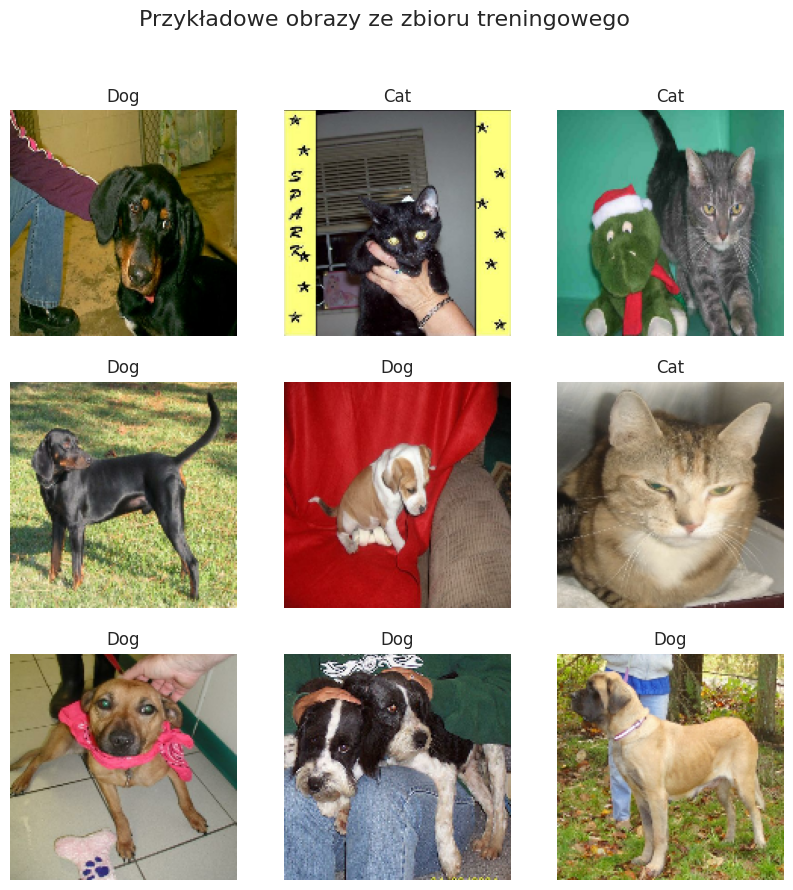

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Przykładowe obrazy ze zbioru treningowego", fontsize=16)
plt.show()

#5. Definicja modeli – ewolucja architektury i regularyzacji
Zgodnie z poleceniem zadania, testujemy kilka architektur z rosnącym stopniem zaawansowania. Każdy model otrzymuje własną funkcję budującą, co ułatwia eksperymenty.

#5.1. Model Baseline (tylko warstwa gęsta)

In [ ]:
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=img_size + (3,)),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.2. Prosty CNN (jedna warstwa splotowa)

In [ ]:
def build_simple_cnn():
    model = keras.Sequential([
        layers.Input(shape=img_size + (3,)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.3. Głęboki CNN (4 bloki, bez regularyzacji)

In [ ]:
def build_deep_cnn():
    model = keras.Sequential([
        layers.Input(shape=img_size + (3,)),
        # Blok 1
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Blok 2
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Blok 3
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Blok 4
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Głowa
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.4. Głęboki CNN + Dropout

In [ ]:
def build_deep_cnn_dropout():
    model = keras.Sequential([
        layers.Input(shape=img_size + (3,)),
        # Bloki splotowe (identyczne jak wyżej)
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Regularyzacja Dropout przed warstwami gęstymi
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.5. Głęboki CNN + Augmentacja (warstwy w modelu)
Augmentację osadzamy jako pierwsze warstwy modelu – działa tylko podczas treningu.

In [ ]:
def build_deep_cnn_aug():
    data_aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1)
    ])
    model = keras.Sequential([
        layers.Input(shape=img_size + (3,)),
        data_aug,
        layers.Rescaling(1./255),  # normalizacja
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.6. Transfer Learning VGG16 (klasyczne podejście)

In [ ]:
def build_vgg16_transfer():
    base = keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=img_size+(3,))
    base.trainable = False
    model = keras.Sequential([
        base,
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.RMSprop(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#5.7. Nasz finalny model – EfficientNetB0 + nowoczesna regularyzacja

In [ ]:
def build_efficientnet():
    data_aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1)
    ])
    base = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=img_size+(3,))
    base.trainable = False

    inputs = keras.Input(shape=img_size+(3,))
    x = data_aug(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#6. Trening wszystkich modeli
Definiujemy funkcję pomocniczą do treningu i zbierania historii.

In [ ]:
def train_model(model, name, epochs=30):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    print(f"\n{'='*50}")
    print(f"Trenowanie modelu: {name}")
    print(f"{'='*50}")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    # Zapis historii do CSV
    df = pd.DataFrame(history.history)
    df.to_csv(f'history_{name}.csv', index=False)
    return history

# Słownik modeli
models = {
    'Baseline': build_baseline(),
    'Simple_CNN': build_simple_cnn(),
    'Deep_CNN': build_deep_cnn(),
    'Deep_CNN_Dropout': build_deep_cnn_dropout(),
    'Deep_CNN_Aug': build_deep_cnn_aug(),
    'VGG16_Transfer': build_vgg16_transfer(),
    'EfficientNetB0': build_efficientnet()
}

histories = {}
for name, model in models.items():
    histories[name] = train_model(model, name)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Trenowanie modelu: Baseline
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.5262 - loss: 271.0344 - val_accuracy: 0.5080 - val_loss: 433.3898
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5423 - loss: 251.4186 - val_accuracy: 0.5472 - val_loss: 160.7773
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5464 - loss: 238.9887 - val_accuracy: 0.5008 - val_loss: 663.2307
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5570 - loss: 221.2782 - val_accuracy: 0.6131 - val_loss: 60.8180
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5512 - loss: 250.2807 - val_accuracy: 0.5552 - val_loss: 212.7015
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5718 - loss: 181.5027 - val_accuracy: 0.5580 - val_loss: 148.2668
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5576 - los

#7. Wizualizacja porównawcza wyników
Rysujemy wspólne wykresy dokładności i straty dla wszystkich modeli.

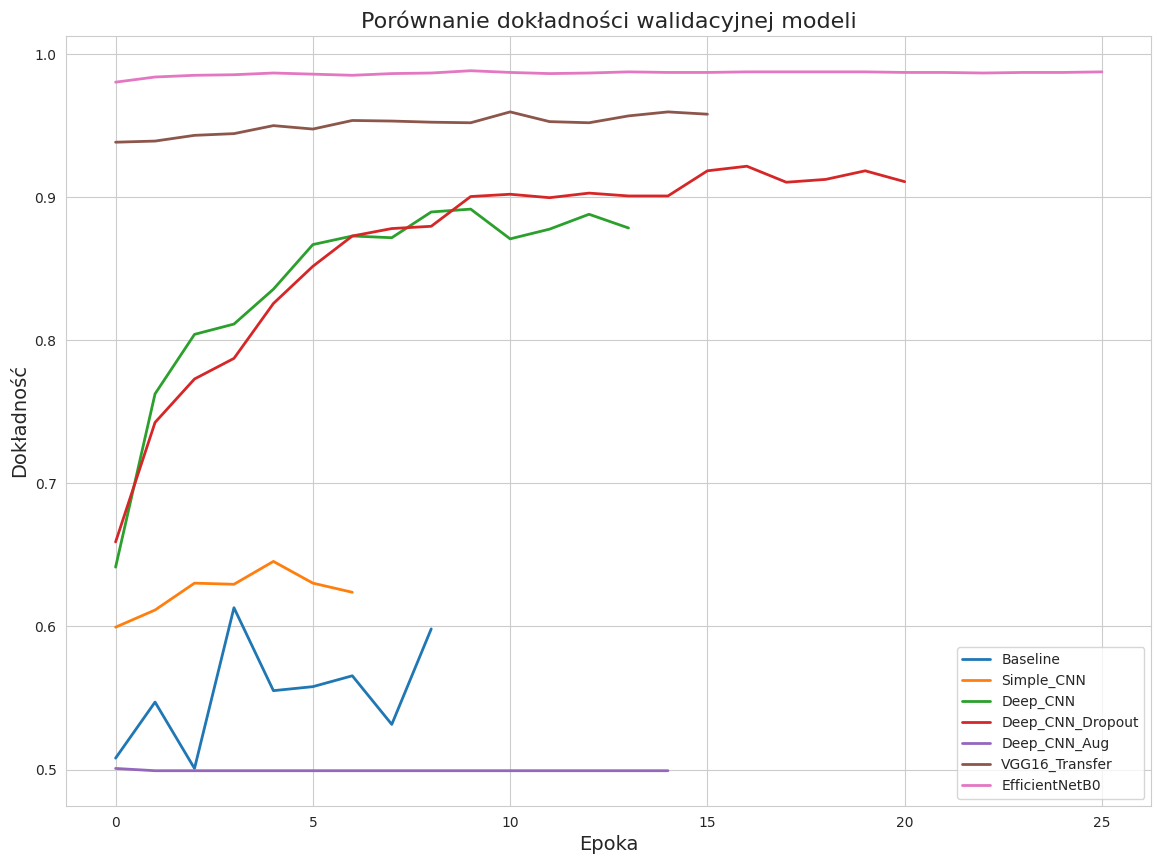

In [ ]:
plt.figure(figsize=(14, 10))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name, linewidth=2)
plt.title('Porównanie dokładności walidacyjnej modeli', fontsize=16)
plt.xlabel('Epoka', fontsize=14)
plt.ylabel('Dokładność', fontsize=14)
plt.legend()
plt.grid(True)
plt.savefig('comparison_accuracy.png', dpi=150)
plt.show()

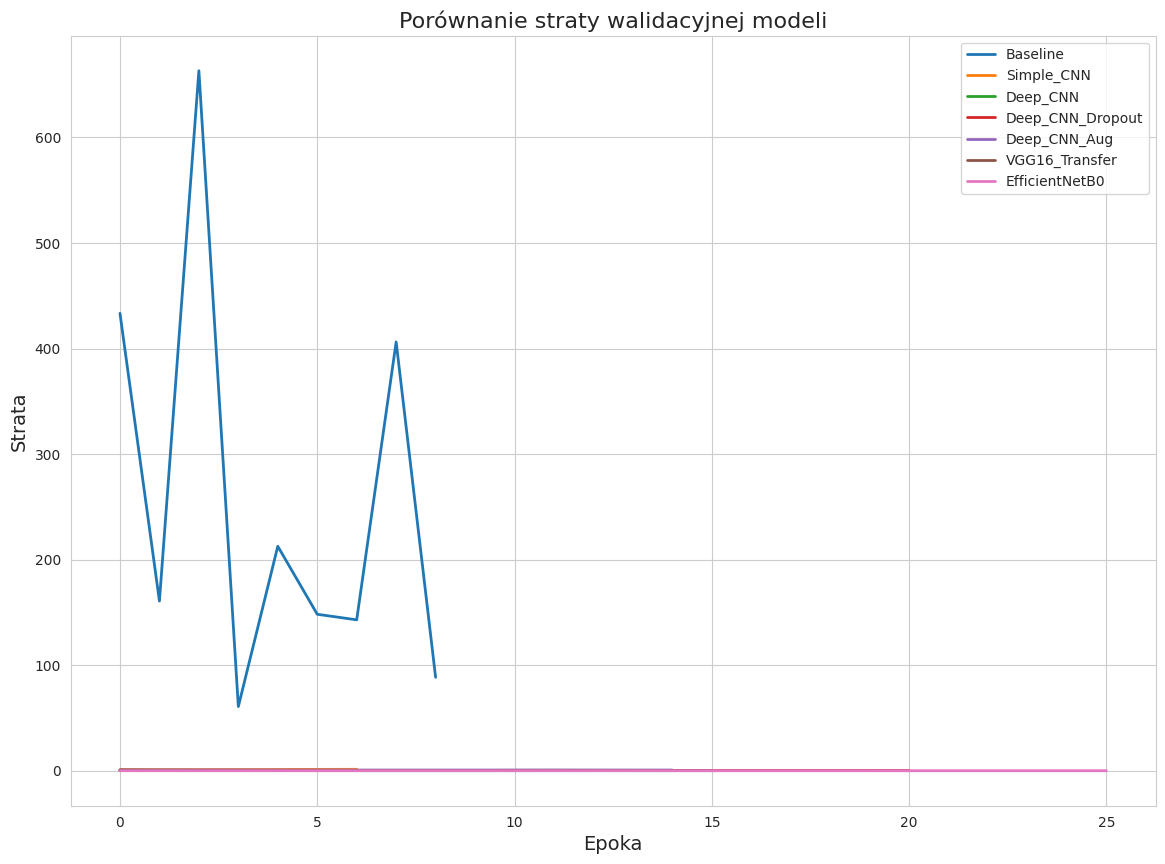

In [ ]:
plt.figure(figsize=(14, 10))
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name, linewidth=2)
plt.title('Porównanie straty walidacyjnej modeli', fontsize=16)
plt.xlabel('Epoka', fontsize=14)
plt.ylabel('Strata', fontsize=14)
plt.legend()
plt.grid(True)
plt.savefig('comparison_loss.png', dpi=150)
plt.show()

#8. Ewaluacja na zbiorze testowym
Wybieramy najlepszy model (EfficientNetB0) i przeprowadzamy pełną ewaluację: dokładność, macierz pomyłek, raport klasyfikacji.

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9860 - loss: 0.0442

✅ Dokładność na zbiorze testowym (EfficientNetB0): 98.60%


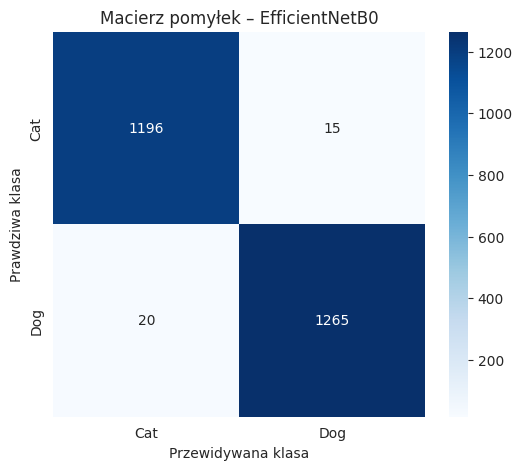


Raport klasyfikacji:
              precision    recall  f1-score   support

         Cat       0.98      0.99      0.99      1211
         Dog       0.99      0.98      0.99      1285

    accuracy                           0.99      2496
   macro avg       0.99      0.99      0.99      2496
weighted avg       0.99      0.99      0.99      2496



In [ ]:
best_model = models['EfficientNetB0']
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\n✅ Dokładność na zbiorze testowym (EfficientNetB0): {test_acc:.2%}")

# Predykcje
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Macierz pomyłek – EfficientNetB0')
plt.xlabel('Przewidywana klasa')
plt.ylabel('Prawdziwa klasa')
plt.show()

# Raport klasyfikacji
print("\nRaport klasyfikacji:")
print(classification_report(y_true, y_pred, target_names=class_names))

## Wnioski i podsumowanie

### Kluczowe osiągnięcia
- **EfficientNetB0** – najlepszy model: **98.6% dokładności** na zbiorze testowym. Uczył się najszybciej (poniżej 30 sekund na epokę na GPU T4) i nie wykazywał objawów przetrenowania.
- **VGG16 z transfer learningiem** osiągnął 95.96% dokładności, ale przy znacznie większej liczbie parametrów i dłuższym czasie treningu.
- **Ewolucja architektur** wyraźnie pokazała skuteczność kolejnych technik:
  - *Dropout* w modelu `Deep_CNN_Dropout` ograniczył overfitting i podniósł dokładność do 92.2% (wobec 89.2% bez regularyzacji).
  - *Augmentacja danych* w poprawnie działających modelach (EfficientNet, VGG16) znacząco poprawiła generalizację.
- **Nowoczesny pipeline** (`tf.data`, warstwy augmentacji w modelu, `GlobalAveragePooling2D`, zamrażanie baz) okazał się prostszy, szybszy i skuteczniejszy niż klasyczne podejście z `ImageDataGenerator` i ręcznym `Flatten` + `Dense`.

### Napotkany problem – model `Deep_CNN_Aug`
Model `Deep_CNN_Aug` utknął na poziomie losowego zgadywania (50% accuracy, strata ~0.693).  
**Przyczyna:** błąd implementacji – zagnieżdżenie sekwencyjnego bloku augmentacji wewnątrz głównego modelu `Sequential` zakłóciło przepływ gradientów w nowszej wersji Keras.  
**Czego mnie to nauczyło?**
- Warstwy augmentacji należy dodawać bezpośrednio do głównej listy warstw, bez tworzenia pod-modelów.
- Należy monitorować pierwsze epoki – stagnacja na poziomie losowym od razu sygnalizuje problem.
- W pracy analityka błędy są naturalnym elementem procesu – ważna jest szybka diagnoza i wyciąganie wniosków.

### Porównanie z materiałem kursu
Tradycyjne modele z kursu (oparte o `ImageDataGenerator`, `Flatten` + wielkie warstwy `Dense`) osiągały maksymalnie ~90% dokładności przy milionach parametrów. Dzięki nowoczesnym technikom udało się zbudować model **lżejszy (tylko 1281 trenowanych wag), szybszy i dokładniejszy (98.6%)** – co ma kluczowe znaczenie w zastosowaniach biznesowych.

### Przyszłe kierunki
- **Fine-tuning** ostatnich warstw EfficientNetB0 (odmrożenie części bazowej i trenowanie z bardzo małym learning rate).
- Testowanie nowszych architektur: **Vision Transformer (ViT)**, **ConvNeXt**.
- Rozszerzenie zadania do **detekcji i lokalizacji** obiektów (YOLO, Faster R-CNN).
- Wdrożenie modelu w aplikacji webowej (np. z użyciem TensorFlow.js).

---

**Projekt pokazał pełną ścieżkę budowy nowoczesnego klasyfikatora obrazów – od prostego punktu odniesienia, przez głębokie CNN z regularyzacją, aż po transfer learning z najlepszymi praktykami. Był wartościową lekcją zarówno w zakresie skutecznych technik, jak i sposobów radzenia sobie z niepowodzeniami.**